# XGBoost Model (square regions)

## Read in data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("../data/eagles_square_modeling_df.csv", index_col=0)
df.drop(columns=['Opp', 'TeamScore', 'OppScore', 'DefTO', 'OffTO', 'Wins', 'Losses','Giants', 'Cowboys', 'TODiff', 'StartTime', "xEndTime"], inplace=True)

df

/var/folders/k9/6ttfwb0s7ssb63rlmgdbybc80000gn/T/ipykernel_27030/1520864787.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/eagles_square_modeling_df.csv", index_col=0)


,date,hour,region,stop_count,Game,Day,Home,PointDiff,Win,OT,...,Streak,Rivalry,RegularSeason,Division,ConfChamp,SuperBowl,gameday,start_hour,end_hour,game_period
2402352,2014-09-07,0,4434_-6395,0,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
2402353,2014-09-07,0,4434_-6394,0,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
2402354,2014-09-07,0,4438_-6399,0,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
2402355,2014-09-07,0,4435_-6398,4,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
2402356,2014-09-07,0,4436_-6399,0,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14433403,2018-02-04,23,4427_-6392,0,SuperBowl,Sunday,0.0,8.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
14433404,2018-02-04,23,4450_-6397,0,SuperBowl,Sunday,0.0,8.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
14433405,2018-02-04,23,4449_-6396,0,SuperBowl,Sunday,0.0,8.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
14433406,2018-02-04,23,4446_-6401,0,SuperBowl,Sunday,0.0,8.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after


In [3]:
df.columns

Index(['date', 'hour', 'region', 'stop_count', 'Game', 'Day', 'Home',
       'PointDiff', 'Win', 'OT', 'Season', 'Streak', 'Rivalry',
       'RegularSeason', 'Division', 'ConfChamp', 'SuperBowl', 'gameday',
       'start_hour', 'end_hour', 'game_period'],
      dtype='object')

## Define features and one-hot encode categorical variables

In [5]:
features = [
    'hour', 'region', 'Day', 'Home',
    'PointDiff', 'Win', 'OT', 'Season', 'Streak',
    'Rivalry', 'RegularSeason', 'Division', 'ConfChamp',
    'SuperBowl', 'start_hour', 'end_hour', 'game_period'
]

X = df[features].copy()
y = df['stop_count']

# Convert categorical text/objects into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['region', 'Day', 'Season', 'game_period'],
                   drop_first=True,
                   dtype=int)

## Do a grouped train/test split (date, hour)

In [7]:
from sklearn.model_selection import GroupShuffleSplit

# Create a unique ID for each date + hour
df['group_id'] = df['date'].astype(str) + "_" + df['hour'].astype(str)

# Use GroupShuffleSplit instead of regular train_test_split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['group_id']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

## XGBoost model

### Fit Model on training data

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define XGBoost hyperparameters
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # standard regression
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.8,
    random_state=42
)

# Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Predictions on test data and round to nearest integer (whole number of stops)

In [10]:
# Predictions
# Standard regression predictions
preds = model.predict(X_test)

# Round predictions to nearest integer
preds_int = np.rint(preds).astype(int)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, preds_int))
mae = mean_absolute_error(y_test, preds_int)
r2 = r2_score(y_test, preds_int)

print(f"R^2 Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")


R^2 Score: 0.1338
Root Mean Squared Error: 0.4494
Mean Absolute Error: 0.0939


### Plot distribution of predictions

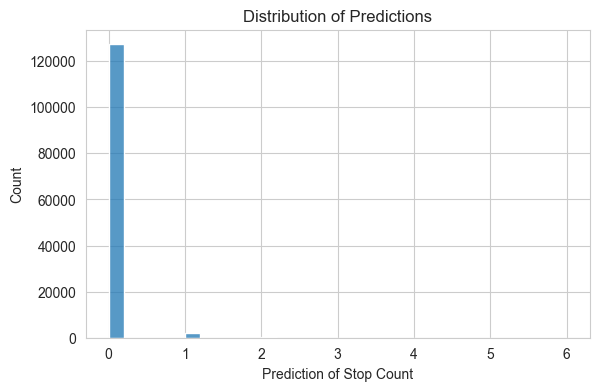

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4))

sns.histplot(preds_int, bins=30, ax=ax)
plt.title(f'Distribution of Predictions')
plt.xlabel('Prediction of Stop Count')
plt.show()